Question 8<br>
Section (a) - Gaussian Smoothing

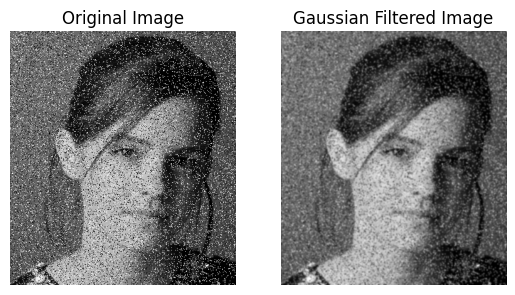

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('emma-noise.jpg', cv.IMREAD_GRAYSCALE)

# applying Gaussian smoothing
kernel_size = 5
sigma = 1.0
padding = kernel_size // 2

ax = np.linspace(-(kernel_size//2), kernel_size//2, kernel_size)
xx, yy = np.meshgrid(ax, ax)

kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
kernel = kernel / np.sum(kernel)  # normalize

img_padded = np.pad(img, padding, mode='edge')

# Apply Gaussian filter
filtered = np.zeros_like(img, dtype=np.float32)
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        window = img_padded[i:i+kernel_size, j:j+kernel_size]
        filtered[i, j] = np.sum(window * kernel)

# Convert back to uint8
filtered = np.clip(filtered, 0, 255).astype(np.uint8)


plot,ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(filtered, cmap='gray')
ax[1].set_title('Gaussian Filtered Image')
ax[1].axis('off')
plt.show()


Section (b) - Median Filtering

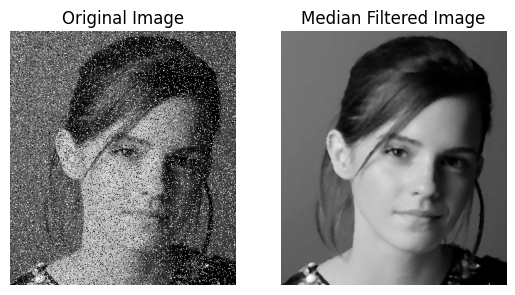

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('emma-noise.jpg', cv.IMREAD_GRAYSCALE)

kernel_size = 5
padding = kernel_size // 2

img_padded = np.pad(img, padding, mode='edge')

filtered = np.zeros_like(img)

# Loop through the image and get get the median applying the kernel
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        window = img_padded[i:i+kernel_size, j:j+kernel_size]
        #get median
        filtered[i,j] = np.median(window)


plot,ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(filtered, cmap='gray')
ax[1].set_title('Median Filtered Image')
ax[1].axis('off')
plt.show()